# Llama Mobile demo

Load a QAT-trained model that has been cast to S3D8 and back to BF16, with optional INT8 activation quantisation. Designed for interactive use / exploration.

You first need to download the checkpoint:

```sh
wget https://graphcore-research-public.s3.eu-west-1.amazonaws.com/2026-llama-mobile/proud-sponge-1878-bf16.safetensors
# or
aws --region=eu-west-1 s3 cp s3://graphcore-research-public/2026-llama-mobile/proud-sponge-1878-bf16.safetensors .
```

_Note: the original QAT checkpoint, with master weights and centroids stored separately can be found under the same prefix, as `proud-sponge-1878.safetensors`._

## Model loading & helpers

In [1]:
from contextlib import contextmanager
import io
import PIL.Image
import requests
import safetensors.torch
import transformers
import torch

In [2]:
# Load standard model from HuggingFace
model = transformers.MllamaForConditionalGeneration.from_pretrained(
    "meta-llama/Llama-3.2-11B-Vision-Instruct", torch_dtype=torch.bfloat16, device_map="auto"
)
processor = transformers.AutoProcessor.from_pretrained(model.config._name_or_path)
model.requires_grad_(False);

The model weights are not tied. Please use the `tie_weights` method before using the `infer_auto_device` function.


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [3]:
# Load quantised weights (skip to use baseline model, or load both if you have sufficient GPU memory)
model.load_state_dict(safetensors.torch.load_file("proud-sponge-1878-bf16.safetensors", device=model.device.type))

<All keys matched successfully>

In [ ]:
# Helper functions for generating from the model, and for enabling activation quantisation

def load_image(url_or_path: str) -> PIL.Image.Image:
    if url_or_path.startswith("http://") or url_or_path.startswith("https://"):
        image = PIL.Image.open(io.BytesIO(requests.get(url_or_path).content)).convert("RGB")
    else:
        image = PIL.Image.open(url_or_path).convert("RGB")
    # Resize to force a single image patch (not strictly necessary, but matches mobile inference usage)
    scale = min(560 / image.width, 560 / image.height)
    image = image.resize((int(image.width * scale), int(image.height * scale)))
    return image


def ask(prompt: str, image: PIL.Image.Image | None = None, max_tokens: int = 100, do_sample: bool = False) -> str:
    message = {
        "role": "user",
        "content": [{"type": "text", "text": prompt}],
    }
    if image is not None:
        message["content"].append({"type": "image"})
    inputs = processor(
        text=processor.apply_chat_template([message], add_generation_prompt=True),
        images=image,
        add_special_tokens=False,
        return_tensors="pt",
    )
    sample_args = {} if do_sample else {"do_sample": False, "temperature": None, "top_p": None}
    outputs = model.generate(**inputs.to(model.device), max_new_tokens=max_tokens, **sample_args)
    return processor.tokenizer.decode(outputs[0], skip_special_tokens=True)


def quantise_channel_int8(x: torch.Tensor) -> torch.Tensor:
    scale = x.abs().amax(dim=tuple(range(x.ndim - 1)), keepdim=True).clamp_min(1e-8) / 127
    q = torch.clamp(torch.round(x / scale), -128, 127).to(torch.int8)
    return q.to(x.dtype) * scale


@contextmanager
def int8_activations(model):
    handles = [
        module.register_forward_pre_hook(lambda _, args: (quantise_channel_int8(args[0]), *args[1:]))
        for module in model.modules()
        if isinstance(module, torch.nn.Linear)
    ]
    try:
        yield
    finally:
        for handle in handles:
            handle.remove()

## Example

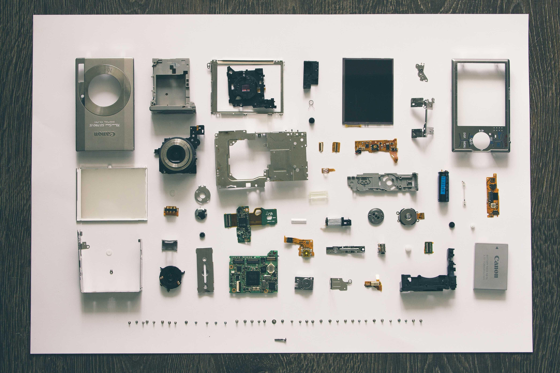

In [6]:
image = load_image("https://picsum.photos/id/36/4179/2790")
display(image)

In [7]:
with int8_activations(model):
    print(ask("What is this an image of?", image))

user

What is this an image of?assistant

This image appears to be a disassembled electronic device, with various components laid out on a white surface. The device is likely a smartphone or tablet, given the presence of a screen, camera, and other common smartphone features. The image may be intended to illustrate the internal workings of the device or to provide a visual guide for repair or maintenance purposes.


In [8]:
# without INT8 activations
print(ask("What is this an image of?", image))

user

What is this an image of?assistant

The image shows a collection of various electronic components, including circuit boards, wires, and other small parts. The components are arranged in a collage style, with some overlapping each other. The background is a light gray color, and the overall atmosphere suggests a technical or industrial setting.


---

## Note - model conversion

<details markdown>

Sync source model:

```sh
aws s3 --region=us-east-1 cp s3://graphcore-research-us-east-1/2024-10-squashedllama/checkpoints/proud-sponge-1878.safetensors .
```

Convert (requires the optimal_formats repo):

```python
import safetensors
import transformers
import torch
import tqdm
import weight_formats.quantisation_training as QT

model = transformers.MllamaForConditionalGeneration.from_pretrained(
    "meta-llama/Llama-3.2-11B-Vision-Instruct", torch_dtype=torch.bfloat16,
)
model.requires_grad_(False)

# Load the QAT checkpoint
QT.load_convert(model, safetensors.torch.load_file("proud-sponge-1878.safetensors"))

# Convert to plain parameters (for the original/unconverted model)
params = {}
with torch.no_grad():
    for name, module in tqdm.tqdm(list(model.named_modules())):
        if isinstance(module, (QT.Weight, QT.Sign3D8Weight, QT.UnquantisedWeight)):
            module.cuda()
            params[name] = module().contiguous().cpu()
            module.cpu()
        else:
            for k, p in module._parameters.items():
                if p is not None:
                    params[".".join(name.split(".") + [k])] = p.cpu()

safetensors.torch.save_file(params, "proud-sponge-1878-bf16.safetensors")
```

</details>